In [22]:
pip install shap


Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


In [24]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [26]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


# Loading important Libraries 

In [35]:

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import shap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [27]:
# Step 2: Load Dataset
df = pd.read_csv('/Users/pranitsalvi/Downloads/yield_df.csv')  
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


# Exploratory Data Analysis (EDA)

In [ ]:
# Overview of dataset
print(" Dataset Shape:", df.shape)
print("\n Column Names:\n", df.columns.tolist())
print("\n Data Types:\n", df.dtypes)
print("\n First 5 Rows:\n", df.head())

# Missing Values
print("\n Missing Values:\n", df.isnull().sum())


 Dataset Shape: (28242, 8)

 Column Names:
 ['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

 Data Types:
 Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

 First 5 Rows:
    Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1485.0              121

In [ ]:
# Descriptive Statistics
print("\n Descriptive Statistics:\n", df.describe(include='all'))

# Unique Values Per Column
print("\n Unique Values per Column:\n", df.nunique())

# Identify Non-Numeric Columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("\n Non-Numeric Columns:\n", non_numeric_cols)


 Descriptive Statistics:
           Unnamed: 0   Area      Item          Year    hg/ha_yield  \
count   28242.000000  28242     28242  28242.000000   28242.000000   
unique           NaN    101        10           NaN            NaN   
top              NaN  India  Potatoes           NaN            NaN   
freq             NaN   4048      4276           NaN            NaN   
mean    14120.500000    NaN       NaN   2001.544296   77053.332094   
std      8152.907488    NaN       NaN      7.051905   84956.612897   
min         0.000000    NaN       NaN   1990.000000      50.000000   
25%      7060.250000    NaN       NaN   1995.000000   19919.250000   
50%     14120.500000    NaN       NaN   2001.000000   38295.000000   
75%     21180.750000    NaN       NaN   2008.000000  104676.750000   
max     28241.000000    NaN       NaN   2013.000000  501412.000000   

        average_rain_fall_mm_per_year  pesticides_tonnes      avg_temp  
count                     28242.00000       28242.000000  2

# Identify Non-Numeric Columns

In [30]:
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("\n Non-Numeric Columns:\n", non_numeric_cols)



 Non-Numeric Columns:
 ['Area', 'Item']


/var/folders/74/sygq3n7x0r9cbzg2vpcgy8t40000gn/T/ipykernel_75003/2885688804.py:6: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


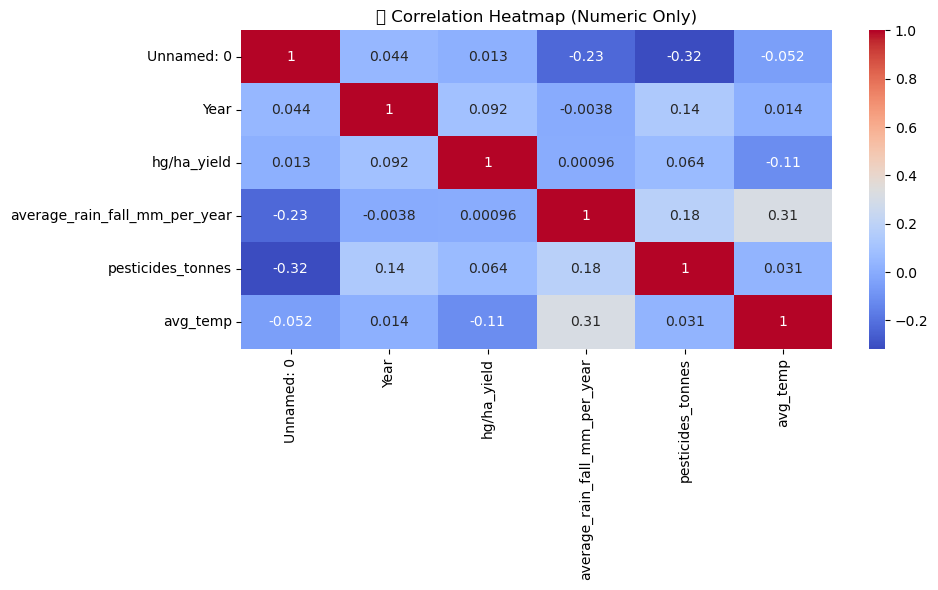

In [ ]:
# Correlation Matrix using only numeric columns
numeric_df = df.select_dtypes(include=[np.number]) 
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("🔗 Correlation Heatmap (Numeric Only)")
plt.tight_layout()
plt.show()

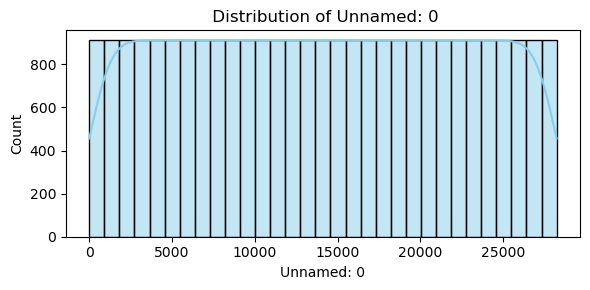

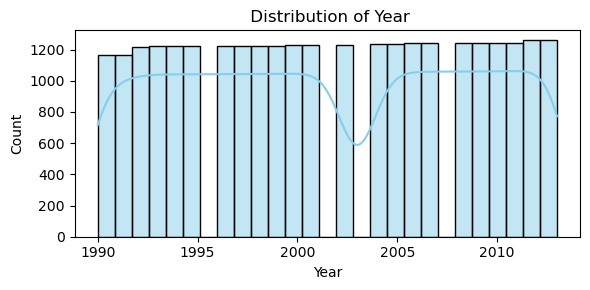

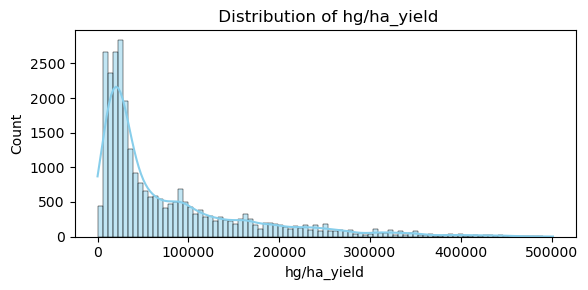

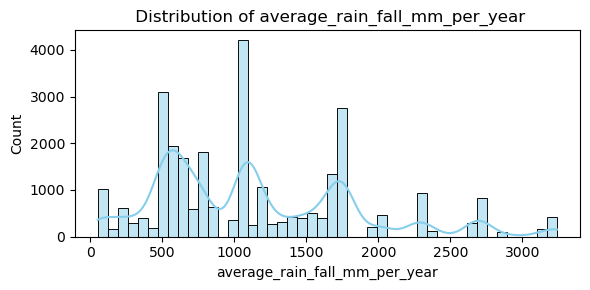

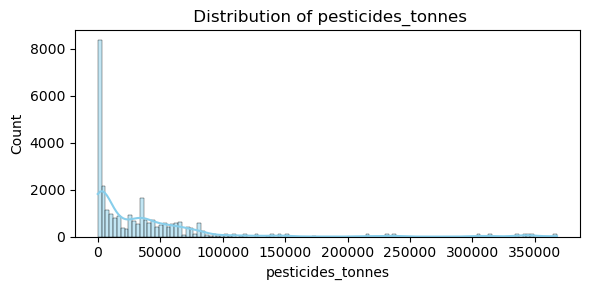

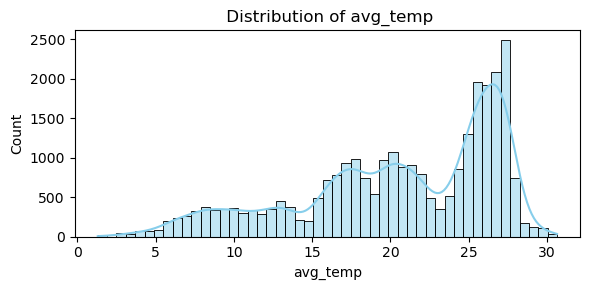

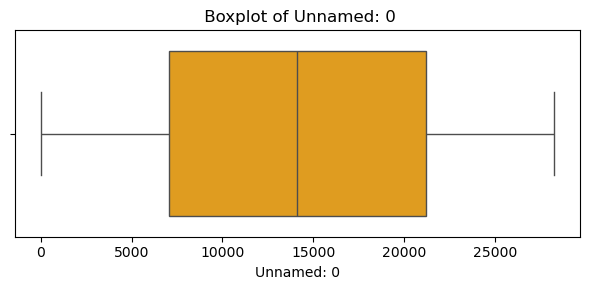

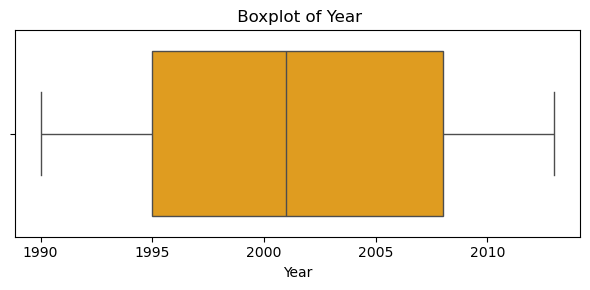

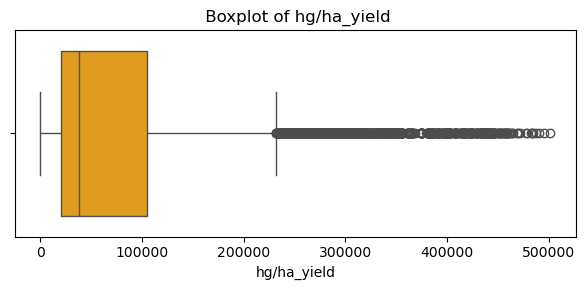

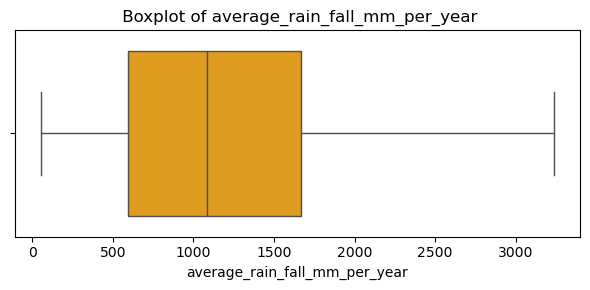

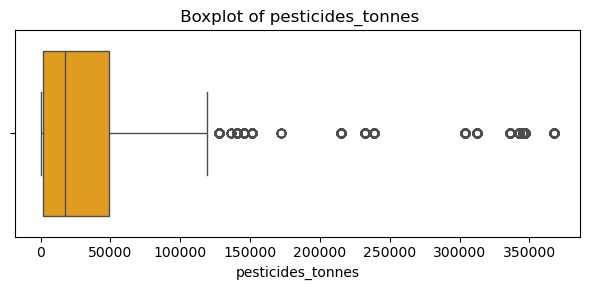

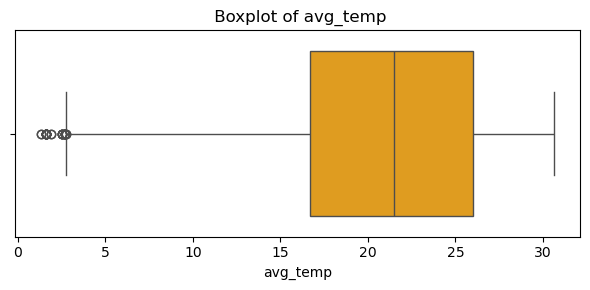

In [ ]:
 # Distribution plots for all numeric columns
for col in numeric_df.columns:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f" Distribution of {col}")
    plt.tight_layout()
    plt.show()

# Boxplots to check for outliers
for col in numeric_df.columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f" Boxplot of {col}")
    plt.tight_layout()
    plt.show()

#  Relationship with target and optional step if your target is numeric i.e. yield
if 'yield' in df.columns and np.issubdtype(df['yield'].dtype, np.number):
    for col in numeric_df.columns:
        if col != 'yield':
            plt.figure(figsize=(6, 3))
            sns.scatterplot(x=df[col], y=df['yield'])
            plt.title(f" Yield vs {col}")
            plt.tight_layout()
            plt.show()

In [ ]:
# Show column names
print(" Column names:\n", df.columns.tolist())

#  Correct target column set
target_col = 'hg/ha_yield'  #  Correct target column

# Define features (X) and target (y)
if target_col in df.columns:
    X = df.drop([target_col], axis=1)
    y = df[target_col]
    print(f"\n Target column '{target_col}' found. Proceeding...")
else:
    raise ValueError(f" Target column '{target_col}' not found! Use one of these:\n{df.columns.tolist()}")


 Column names:
 ['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

 Target column 'hg/ha_yield' found. Proceeding...


# Model Training and Performance Evaluation: Linear Regression, Random Forest, and MLP Neural Network

In [ ]:
# Convert categorical columns to numeric (one-hot encoding)
X = pd.get_dummies(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Train MLP Neural Network
mlp = MLPRegressor(hidden_layer_sizes=(64, 64), activation='relu',
                   max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n {model_name} Performance:")
    print(f"R² Score: {r2_score(y_true, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")

# Evaluate all models
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_mlp, "MLP Neural Network")



 Linear Regression Performance:
R² Score: 0.7548
MAE: 29673.6601
RMSE: 42169.2836

 Random Forest Performance:
R² Score: 0.9890
MAE: 3251.1500
RMSE: 8925.4678

 MLP Neural Network Performance:
R² Score: 0.8742
MAE: 18791.1626
RMSE: 30206.9131


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


# Dataset Preprocessing & Feature Engineering

In [ ]:
df.isnull().sum()  
df.dropna()


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.00,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.00,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.00,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.00,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.00,16.37
...,...,...,...,...,...,...,...,...
28237,28237,Zimbabwe,"Rice, paddy",2013,22581,657.0,2550.07,19.76
28238,28238,Zimbabwe,Sorghum,2013,3066,657.0,2550.07,19.76
28239,28239,Zimbabwe,Soybeans,2013,13142,657.0,2550.07,19.76
28240,28240,Zimbabwe,Sweet potatoes,2013,22222,657.0,2550.07,19.76


# Encode Categorical Variables

In [36]:
df_encoded = pd.get_dummies(df, columns=['Area', 'Item'], drop_first=True)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded.drop(['hg/ha_yield'], axis=1))
df['log_pesticides'] = np.log1p(df['pesticides_tonnes'])


# Multicollinearity Check

/Users/pranitsalvi/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


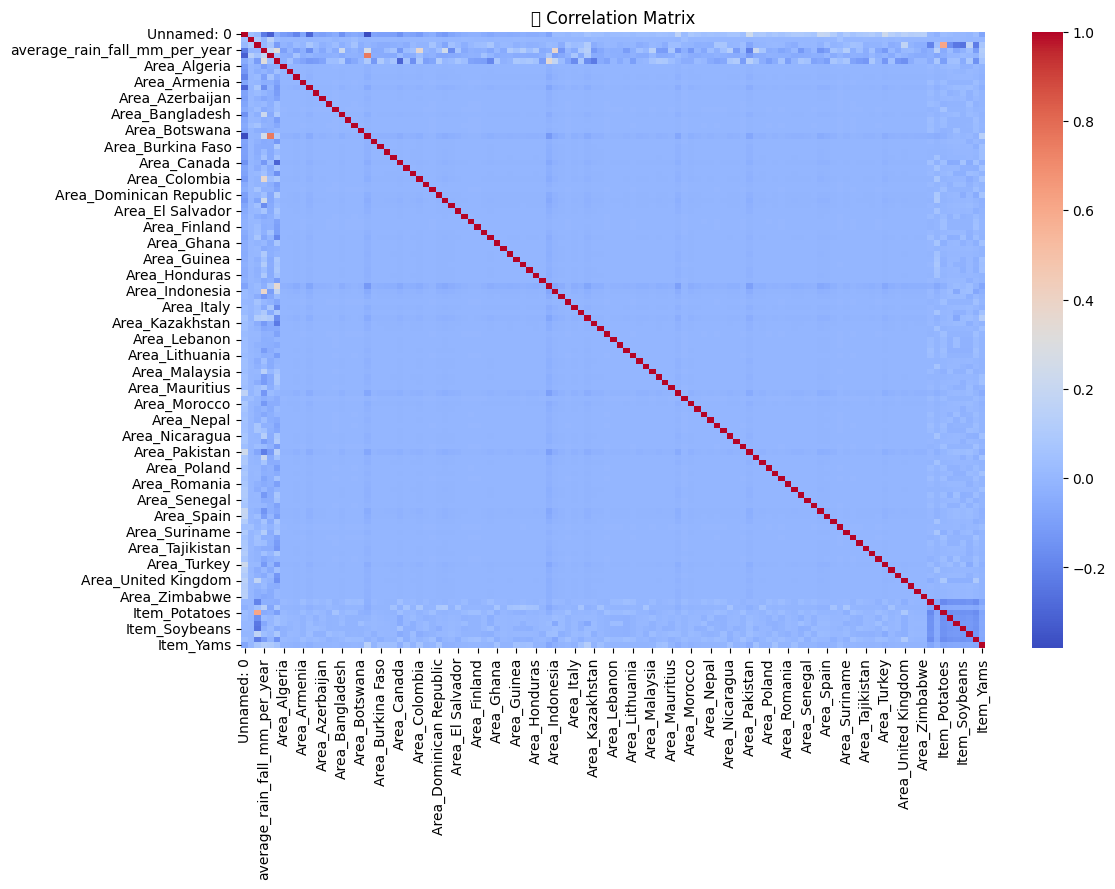

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title("🔗 Correlation Matrix")
plt.show()
X = df_encoded.drop(['hg/ha_yield'], axis=1)
y = df_encoded['hg/ha_yield']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Models

In [38]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# MLP Regressor
mlp = MLPRegressor(hidden_layer_sizes=(64, 64), activation='relu', max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


# Evaluate Models

In [ ]:
def evaluate(y_true, y_pred, model_name):
    print(f"\n {model_name} Performance")
    print(f"R² Score: {r2_score(y_true, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_mlp, "MLP Neural Network")


 Linear Regression Performance
R² Score: 0.7549
MAE: 29668.17
RMSE: 42164.85

 Random Forest Performance
R² Score: 0.9890
MAE: 3232.56
RMSE: 8945.38

 MLP Neural Network Performance
R² Score: 0.7598
MAE: 25899.69
RMSE: 41742.62


# Random Forest: Actual vs Predicted Yield

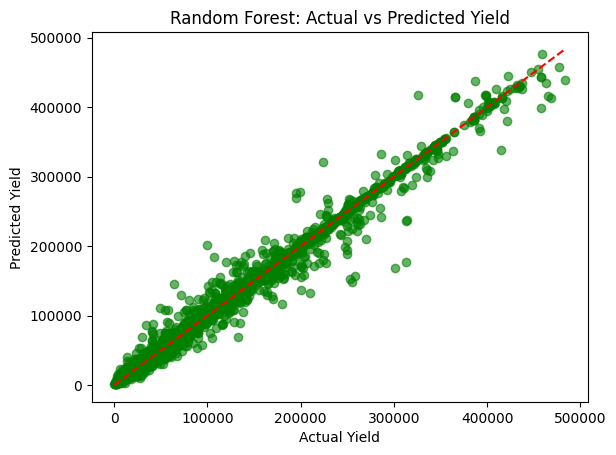

In [ ]:
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest: Actual vs Predicted Yield")
plt.show()

# Hyperparameter Tuning

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
param_grid = {
    'hidden_layer_sizes': [(64,), (64, 64), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001]
}

Best Params: {'max_depth': None, 'n_estimators': 200}


# Cross-Validation for Model Reliability

In [ ]:
from sklearn.model_selection import cross_val_score

# Cross-validation on Random Forest
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(" Random Forest CV R² Scores:", cv_scores_rf)
print("Average CV R²:", np.mean(cv_scores_rf))

 Random Forest CV R² Scores: [0.62515606 0.5455694  0.85761519 0.6893448  0.65454468]
Average CV R²: 0.6744460253707337


# Comparistion Hyperparameter Tuning 

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(" Best Parameters:", grid_search.best_params_)

# Retrain with best model
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

 Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


# Feature Importance (Random Forest or XGBoost)

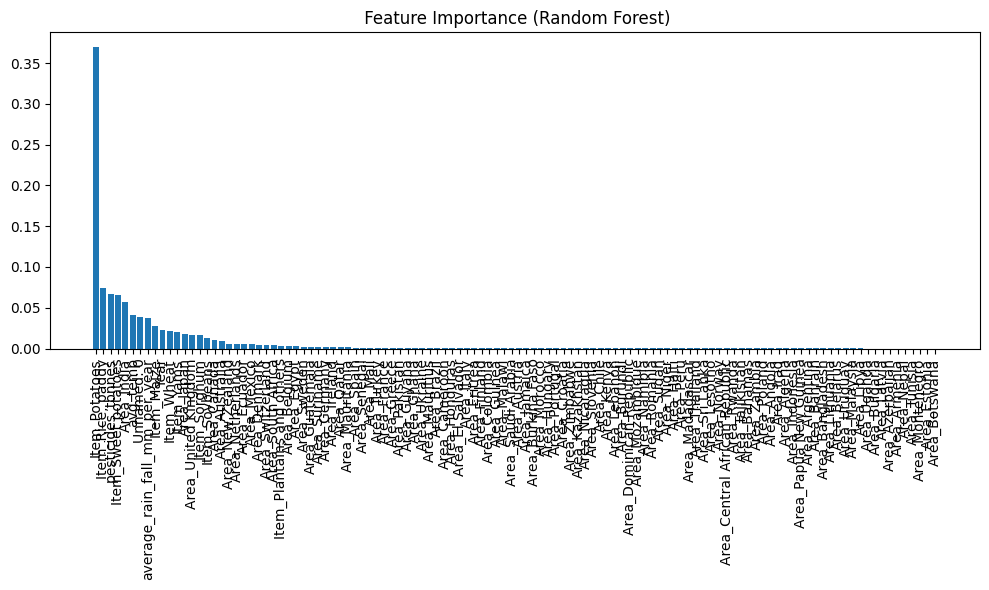

In [ ]:
importances = best_rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title(" Feature Importance (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()

# Residual Analysis

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


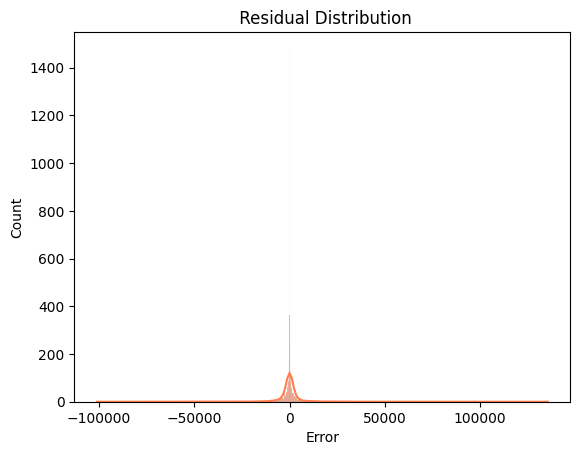

 Model saved successfully.


In [ ]:
residuals = y_test - y_pred_best_rf
sns.histplot(residuals, kde=True, color='coral')
plt.title(" Residual Distribution")
plt.xlabel("Error")
plt.show()
joblib.dump(best_rf, 'best_random_forest_model.pkl')
print(" Model saved successfully.")

# SHAP for Feature Impact Visualization (Explainable AI)

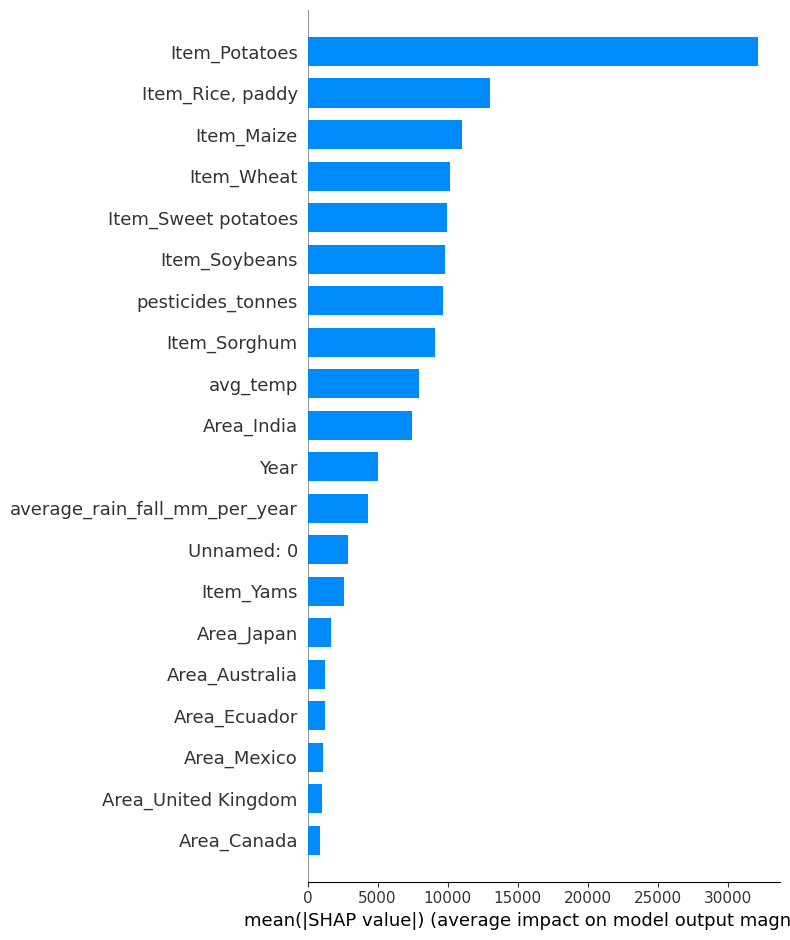

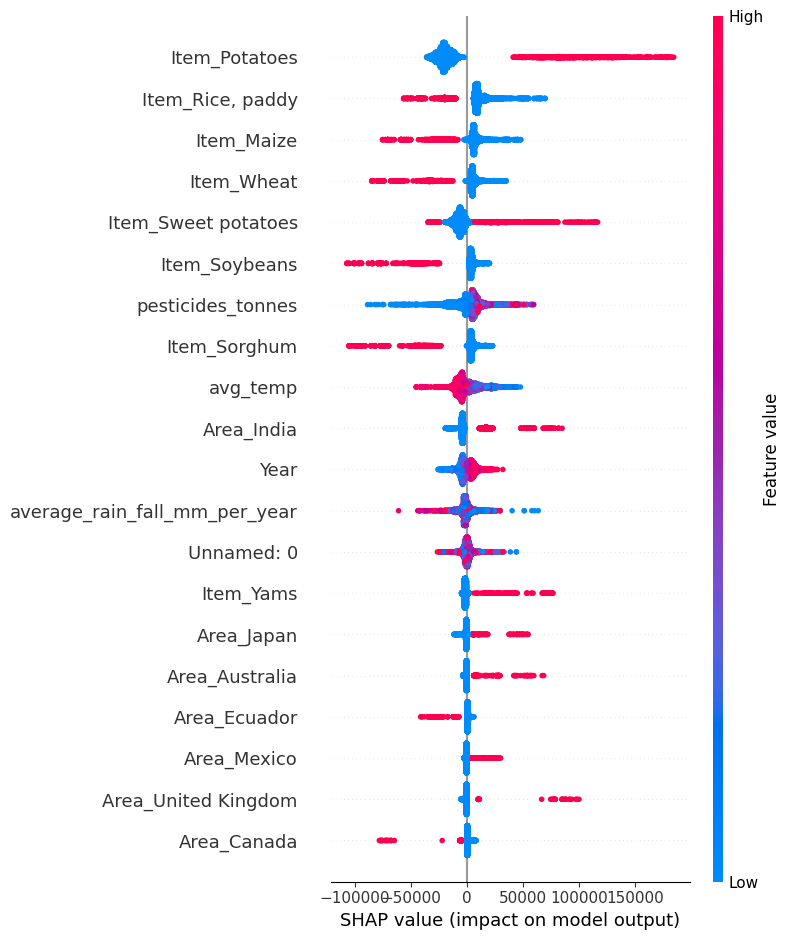

In [ ]:
import shap

# Initialize the explainer with your trained model
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Visualize global feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Visualize impact of features across samples
shap.summary_plot(shap_values, X_test)


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display

# Save feature names BEFORE scaling
feature_names = X.columns.tolist()  

# Make sure you're using the scaled NumPy array (X_train)
explainer = LimeTabularExplainer(
    training_data=X_train,             # must be a NumPy array
    feature_names=feature_names,       
    mode='regression',
    verbose=True,
    random_state=42
)

# Explain one instance
i = 0
exp = explainer.explain_instance(
    data_row=X_test[i],                
    predict_fn=rf.predict,             
    num_features=5
)

Intercept 423921.234691977
Prediction_local [30954.54790681]
Right: 71267.74


# LSTM Neural Network Implementation Framework:

Epoch 1/30


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


565/565 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 12968487936.0000 - val_loss: 12263875584.0000
Epoch 2/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 10260291584.0000 - val_loss: 6564517888.0000
Epoch 3/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4939873280.0000 - val_loss: 3001078528.0000
Epoch 4/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2435245056.0000 - val_loss: 1915985664.0000
Epoch 5/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1572853248.0000 - val_loss: 1402034048.0000
Epoch 6/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1246234368.0000 - val_loss: 1083111424.0000
Epoch 7/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 924499072.0000 - val_loss: 865239872.0000
Epoch 8/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 791052672.0000 - val_loss: 717334144.0000
Epoch 9/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 684963136.0000 - val_loss: 614426240.0000
Epoch 10/30
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 579482368.0000 - 

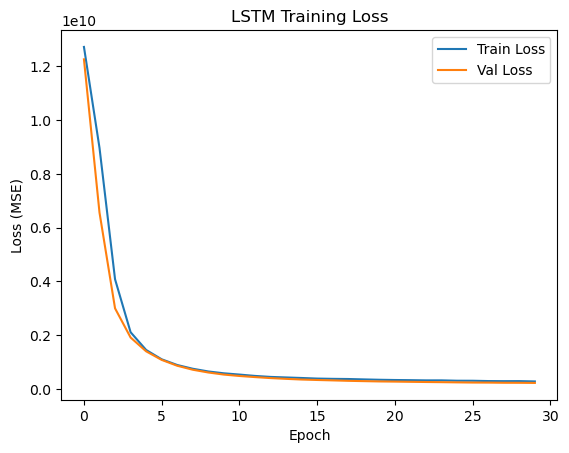

In [39]:

# Sort by Area, Item, Year to simulate time series structure
df = df.sort_values(by=["Area", "Item", "Year"])

# Encode categorical variables
df = pd.get_dummies(df, columns=["Area", "Item"])

# Feature/target separation
X = df.drop(columns=["hg/ha_yield"])
y = df["hg/ha_yield"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for LSTM: (samples, timesteps, features)
# Here we assume 1 timestep per row (this is a simplification)
X_scaled = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Build LSTM model
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Output layer for regression

model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

# Predict and evaluate
y_pred = model.predict(X_test).flatten()

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n LSTM Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Optional: Plot training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.show()
